# CityPulse AI: a first look at Citi Bike data

CityPulse AI aims to understand urban mobility and eventually forecast bike-trip demand using NYC Citi Bike trips and historical weather. This notebook begins with a tiny preview, then preserves the data-quality checks and hourly-demand visualization developed with a mentor.

## What is our dataset?

Our three local files in `csv_files/`, named `202502-citibike-tripdata_1.csv` through `202502-citibike-tripdata_3.csv`, contain the February 2025 trip-data parts. A CSV (comma-separated values) stores a table as text: the first line names the columns, and the following records contain data. We will inspect five records to see the actual columns and values rather than assume the schema.

## What does EDA mean?

**Exploratory data analysis (EDA)** means looking at data to understand what it contains, ask questions, and notice patterns or potential quality issues before building models. This notebook starts that process with a five-row preview. A small preview does not tell us the full dataset's size, quality, or patterns.

Run the cells from top to bottom using **Shift + Enter**. Select the **CityPulse AI (.venv)** kernel so the notebook uses our existing Python environment. The first read loads only five rows. Later cells scan the local files in chunks or with DuckDB. Saved results are retained; continue the EDA step by step with your mentor.


## 1. Import our tools

`pandas` helps us read CSV files and work with tables called **DataFrames**. We use the short name `pd`. `Path` from Python's `pathlib` module helps us work with file and folder paths.


In [1]:
import pandas as pd
from pathlib import Path


## 2. Locate our Citi Bike CSV files

Jupyter may start in the project folder or the `notebooks/` folder. We find the project root first, then list the CSV files in its `csv_files/` folder. This lists paths without reading the CSV contents. The synthetic ETL fixtures are excluded.

The current February 2025 dataset has three parts. If no files are found, place the extracted Citi Bike CSV files in `csv_files/` at the project root.


In [2]:
project_root = next(
    (
        folder
        for folder in (Path.cwd(), *Path.cwd().parents)
        if (folder / "pyproject.toml").is_file()
        and (folder / "src" / "citypulse_ai").is_dir()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("Start Jupyter inside the CityPulse-AI project folder.")

data_folder = project_root / "csv_files"
csv_files = sorted(data_folder.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError("No Citi Bike CSV files found in csv_files/ at the project root.")

[path.relative_to(project_root).as_posix() for path in csv_files]


['csv_files/202502-citibike-tripdata_1.csv',
 'csv_files/202502-citibike-tripdata_2.csv',
 'csv_files/202502-citibike-tripdata_3.csv']

## 3. Read only five rows from one CSV

We select the first file from the sorted list. `nrows=5` tells pandas to read **at most five data rows**, instead of loading the whole file. `dtype="string"` keeps the preview as text, preserving identifiers such as station IDs with leading zeros. We are not parsing timestamps or cleaning data yet.


In [3]:
csv_path = csv_files[0]
preview = pd.read_csv(csv_path, nrows=5, dtype="string")


## 4. Display the preview as a table

Putting the DataFrame name on the last line lets Jupyter display it as a table. Column headings come from the CSV header. The numbers on the left are pandas row labels, not ride IDs. A blank CSV value may appear as `<NA>`, pandas' missing-value marker.

Pause here and review the columns with your mentor. These five rows are a preview, not a representative sample or a complete quality check.


In [4]:
preview


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,CB5406D3D5F737FD,electric_bike,2025-02-02 00:19:27.351,2025-02-02 00:31:15.349,Windsor Pl & 8 Ave,3620.02,New York Ave & Hawthorne St,3504.02,40.660906,-73.983074,40.65794,-73.94735,member
1,C121FE82B33D3C0B,classic_bike,2025-02-12 14:21:54.750,2025-02-12 14:36:30.914,N 5 St & Wythe Ave,5419.04,Bushwick Ave & Stagg St,5140.06,40.718389,-73.961501,40.709897,-73.94008,member
2,3ABBEFFA37358AF5,electric_bike,2025-02-10 19:01:06.941,2025-02-10 19:10:11.898,W 82 St & Central Park W,7304.08,E 75 St & 3 Ave,6991.12,40.78275,-73.97137,40.77112927,-73.95772297,member
3,35C2CFDA66D8E492,electric_bike,2025-02-01 18:25:35.756,2025-02-01 18:43:23.495,Classon Ave & St Marks Ave,4074.14,Central Ave & Melrose St,4832.07,40.676513,-73.959431,40.70112,-73.93039,member
4,91524588E010013A,electric_bike,2025-02-11 08:44:16.954,2025-02-11 08:56:33.197,8 Ave & W 33 St,6450.12,Madison Ave & E 51 St,6659.09,40.751551,-73.993934,40.75863,-73.97513,member


In [5]:
print("Number of CSV files:", len(csv_files))

print("Preview shape:", preview.shape)

print("\nColumn names:")
print(preview.columns.tolist())

Number of CSV files: 3
Preview shape: (5, 13)

Column names:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


In [6]:
# Reuse the project-root discovery above instead of searching again.
print("Jupyter is running from:", Path.cwd())
print("Dataset folder:", data_folder)
print("Number of CSV files:", len(csv_files))

for file in csv_files:
    print(file.name)


Jupyter is running from: /Users/sanjeevani1109/Desktop/Masters/Projects/CityPulse-AI/notebooks
Dataset folder: /Users/sanjeevani1109/Desktop/Masters/Projects/CityPulse-AI/csv_files
Number of CSV files: 3
202502-citibike-tripdata_1.csv
202502-citibike-tripdata_2.csv
202502-citibike-tripdata_3.csv


In [7]:
file_counts = []

for file in csv_files:
    count = 0

    for chunk in pd.read_csv(
        file,
        usecols=["ride_id"],
        chunksize=100_000
    ):
        count += len(chunk)

    file_counts.append({
        "File": file.name,
        "Number of Rides": count
    })

summary = pd.DataFrame(file_counts)

display(summary)

print("Total rides:", summary["Number of Rides"].sum())

,File,Number of Rides
0,202502-citibike-tripdata_1.csv,1000000
1,202502-citibike-tripdata_2.csv,1000000
2,202502-citibike-tripdata_3.csv,31257


Total rides: 2031257


In [8]:
# Create a counter for missing values in every column
missing_counts = pd.Series(0, index=preview.columns)

total_rows = 0

# Read all three CSV files in chunks
for file in csv_files:
    for chunk in pd.read_csv(
        file,
        chunksize=100_000,
        dtype="string"
    ):
        total_rows += len(chunk)

        # Count missing values in each column
        missing_counts += chunk.isna().sum()

# Create a summary table
missing_report = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": (missing_counts / total_rows * 100).round(2)
})

display(missing_report.sort_values("Missing Count", ascending=False))

,Missing Count,Missing %
end_station_id,4777,0.24
end_lat,4756,0.23
end_lng,4756,0.23
end_station_name,4454,0.22
start_station_name,673,0.03
start_station_id,673,0.03
start_lat,673,0.03
start_lng,673,0.03
ride_id,0,0.00
rideable_type,0,0.00


In [9]:
import duckdb

# Connect to DuckDB
con = duckdb.connect()

# Find all three CSV files
csv_pattern = str(data_folder / "*.csv")

# Analyse ride IDs across all files
duplicates = con.execute("""
    WITH trips AS (
        SELECT NULLIF(TRIM(ride_id), '') AS ride_id
        FROM read_csv(?, all_varchar=true)
    )
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT ride_id) AS unique_rides,
        COUNT(ride_id) - COUNT(DISTINCT ride_id) AS duplicate_extras,
        COUNT(*) - COUNT(ride_id) AS missing_ids
    FROM trips
""", [csv_pattern]).df()

display(duplicates)

,total_rows,unique_rides,duplicate_extras,missing_ids
0,2031257,2031257,0,0


In [10]:
duration_check = con.execute("""
    WITH trips AS (
        SELECT
            TRY_CAST(started_at AS TIMESTAMP) AS start_time,
            TRY_CAST(ended_at AS TIMESTAMP) AS end_time
        FROM read_csv(?, all_varchar=true)
    )
    SELECT
        COUNT(*) AS total_rides,

        COUNT(*) FILTER (
            WHERE start_time IS NULL OR end_time IS NULL
        ) AS invalid_timestamps,

        COUNT(*) FILTER (
            WHERE end_time <= start_time
        ) AS invalid_durations,

        COUNT(*) FILTER (
            WHERE date_diff('minute', start_time, end_time) > 1440
        ) AS rides_over_24_hours

    FROM trips
""", [csv_pattern]).df()

display(duration_check)

,total_rides,invalid_timestamps,invalid_durations,rides_over_24_hours
0,2031257,0,0,315


,hour,ride_starts
0,2025-02-01 00:00:00,1535
1,2025-02-01 01:00:00,1071
2,2025-02-01 02:00:00,765
3,2025-02-01 03:00:00,491
4,2025-02-01 04:00:00,335


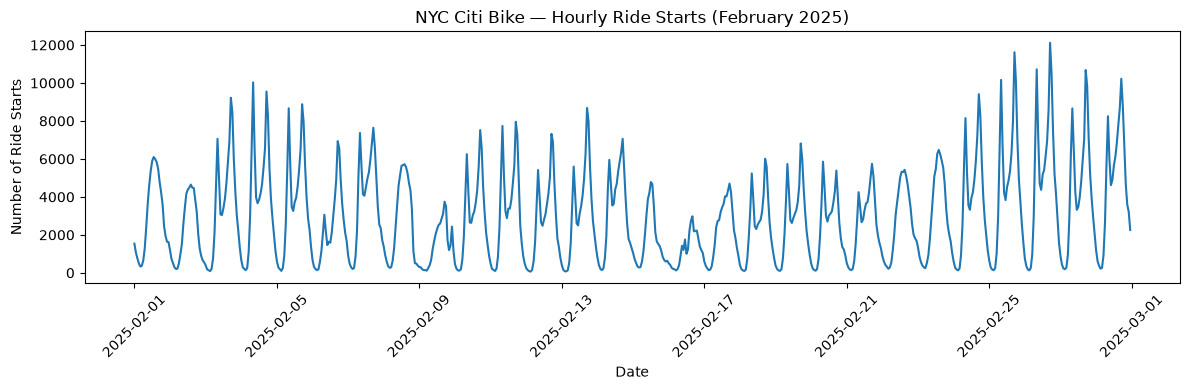

In [11]:
import matplotlib.pyplot as plt

# Aggregate individual rides into hourly totals
hourly_demand = con.execute("""
    SELECT
        DATE_TRUNC(
            'hour',
            TRY_CAST(started_at AS TIMESTAMP)
        ) AS hour,
        COUNT(*) AS ride_starts

    FROM read_csv(?, all_varchar=true)

    WHERE TRY_CAST(started_at AS TIMESTAMP)
          >= TIMESTAMP '2025-02-01'
      AND TRY_CAST(started_at AS TIMESTAMP)
          < TIMESTAMP '2025-03-01'

    GROUP BY hour
    ORDER BY hour
""", [csv_pattern]).df()

# Preview the data
display(hourly_demand.head())

# Plot the time series
plt.figure(figsize=(12, 4))

plt.plot(
    hourly_demand["hour"],
    hourly_demand["ride_starts"]
)

plt.title("NYC Citi Bike — Hourly Ride Starts (February 2025)")
plt.xlabel("Date")
plt.ylabel("Number of Ride Starts")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print("Hourly data available:", "hourly_demand" in globals())

Hourly data available: True


day_type,Weekday,Weekend
hour_of_day,,
0,613.0,1026.0
1,300.0,704.0
2,183.0,477.0
3,128.0,315.0
4,211.0,238.0
5,784.0,243.0
6,2132.0,483.0
7,4528.0,956.0
8,6826.0,1725.0


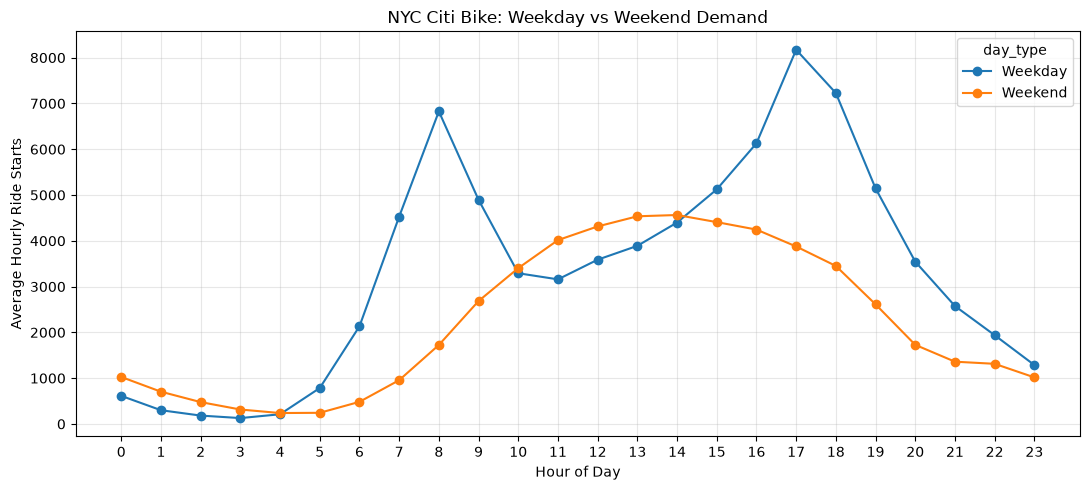

In [13]:
# Create a copy of our hourly dataset
hourly = hourly_demand.copy()

# Extract the hour of day (0-23)
hourly["hour_of_day"] = hourly["hour"].dt.hour

# Identify weekdays vs weekends
hourly["day_type"] = hourly["hour"].dt.dayofweek.map(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Calculate average demand by hour and day type
avg_demand = hourly.groupby(
    ["hour_of_day", "day_type"]
)["ride_starts"].mean().unstack()

# Display results
display(avg_demand.round(0))

# Visualize
avg_demand.plot(figsize=(11, 5), marker="o")

plt.title("NYC Citi Bike: Weekday vs Weekend Demand")
plt.xlabel("Hour of Day")
plt.ylabel("Average Hourly Ride Starts")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings: Weekday vs Weekend Demand

- Weekday demand exhibits a bimodal pattern, with
  prominent peaks around 08:00 and 17:00,
  consistent with typical commuting hours.
- Evening weekday demand is higher than morning
  demand.
- Weekend demand follows a smoother pattern,
  increasing through the morning and peaking
  during the early-to-mid afternoon.
- Late-night demand is generally higher on
  weekends than on weekdays.

These findings suggest that hour of day, day of
week, and weekend indicators may be useful
predictors for demand forecasting.

However, the behavioural explanations are
hypotheses rather than established causal effects.

In [5]:
from pathlib import Path
import duckdb

# Locate our CSV folder
data_folder = Path.cwd() / "csv_files"

# If Jupyter is running from the notebooks folder
if not data_folder.exists():
    data_folder = Path.cwd().parent / "csv_files"

# Find all three CSV files
csv_files = sorted(data_folder.glob("*.csv"))
csv_pattern = str(data_folder / "*.csv")

# Connect to DuckDB
con = duckdb.connect()

print("CSV files found:", len(csv_files))
print("DuckDB connection ready!")

CSV files found: 3
DuckDB connection ready!


In [6]:
top_stations = con.execute("""
    SELECT
        start_station_id,
        COUNT(*) AS total_rides
    FROM read_csv(?, all_varchar=true)
    WHERE start_station_id IS NOT NULL
      AND TRIM(start_station_id) != ''
    GROUP BY start_station_id
    ORDER BY total_rides DESC
    LIMIT 10
""", [csv_pattern]).df()

display(top_stations)

,start_station_id,total_rides
0,6140.05,8811
1,6233.04,7761
2,5788.13,7190
3,6331.01,7004
4,6492.08,6502
5,5905.12,6447
6,5779.11,6414
7,5905.14,5970
8,6197.08,5961
9,5303.06,5740


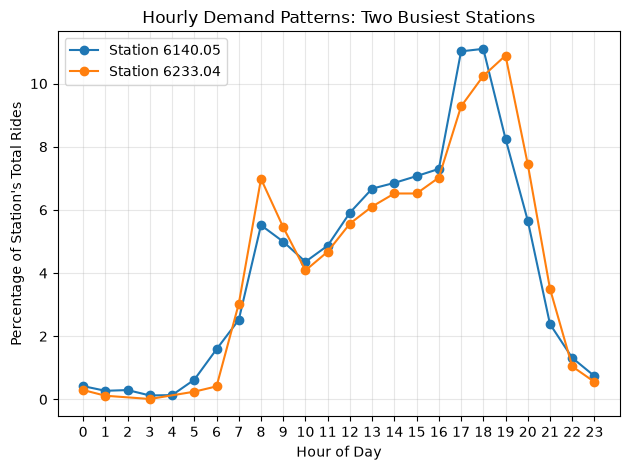

In [7]:
import matplotlib.pyplot as plt

# Select the two busiest stations
station_ids = top_stations["start_station_id"].head(2).tolist()

# Count rides by station and hour of day
station_hourly = con.execute("""
    SELECT
        start_station_id,
        EXTRACT(HOUR FROM TRY_CAST(started_at AS TIMESTAMP))
            AS hour_of_day,
        COUNT(*) AS rides
    FROM read_csv(?, all_varchar=true)
    WHERE start_station_id IN (?, ?)
    GROUP BY 1, 2
    ORDER BY 1, 2
""", [csv_pattern, *station_ids]).df()

# Calculate the percentage of each station's rides
# occurring during each hour
station_hourly["share_pct"] = (
    station_hourly.groupby("start_station_id")["rides"]
    .transform(lambda x: x / x.sum() * 100)
)

# Compare hourly patterns
for station_id, group in station_hourly.groupby("start_station_id"):
    plt.plot(
        group["hour_of_day"],
        group["share_pct"],
        marker="o",
        label=f"Station {station_id}"
    )

plt.title("Hourly Demand Patterns: Two Busiest Stations")
plt.xlabel("Hour of Day")
plt.ylabel("Percentage of Station's Total Rides")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Key Findings: Station-Level Demand

- Both stations exhibit similar daily demand patterns, with
  low overnight activity and strong evening peaks.
- Station 6140.05 experiences a pronounced demand increase
  around 17:00 and peaks between 17:00 and 18:00.
- Station 6233.04 reaches its highest relative demand
  around 19:00, suggesting a later evening peak.
- These differences indicate that station-specific temporal
  patterns may be valuable for demand forecasting.

The analysis covers February 2025 only, and the observed
patterns do not establish the causes of rider behaviour.

In [8]:
from pathlib import Path
import duckdb

# Locate our project
root = Path.cwd()

if root.name == "notebooks":
    root = root.parent

# Connect to our processed database
db_path = root / "outputs/phase13-first-file/citypulse.duckdb"

with duckdb.connect(str(db_path), read_only=True) as con:
    result = con.execute("""
        SELECT
            COUNT(*) AS station_hour_rows,
            SUM(ride_count) AS total_ride_starts
        FROM hourly_rides
    """).df()

display(result)

,station_hour_rows,total_ride_starts
0,299800,999578.0
